In [8]:
import numpy as np;
import matplotlib.pyplot as plt
import pandas as pd

# Physical constants
G_GRAVITY = 9.8  # m/s²
DEFAULT_TRUNK_LENGTH = 0.77  # m
DEFAULT_K_FACTOR = 0.27  # trunk moment arm factor
L5S1_LIMIT_N = 3400.0  # N, maximum compressive force at L5/S1


# Safe Lifting Analysis - Biomechanical Load Evaluation


## Abstract
Incorrect lifting often causes low back pain. This project develops and tests a static biomechanical model for manual lifting risk at the L5-S1 spinal segment. Using formulas adapted from *A Biomechanical Waist Comfort Model for Manual Material Lifting* (Zhang et al., 2020), we quantify erector spinae force, lifting index, and a comfort score as functions of object mass and lifting height.


## 1. Problem formulation and significance
Low-back pain is strongly associated with manual material handling. In ergonomics, the L5-S1 lumbar segment is commonly used as a risk-critical point.

### Research question
How do object weight and lifting height affect lumbar loading and safety margin during stoop lifting?

### Objectives
- Implement a reproducible biomechanical force model for L5-S1 loading.
- Compute recommended weight limit (RWL), lifting index (LI), and waist comfort score.
- Evaluate risk across realistic lifting configurations.
- Define risk metrics and analyze sensitivity across posture and object weight.
- Present results with clear bullets and plots.



## 2. Model equations and assumptions

### 2.1. Equilibrium condition
The net moment around the L5-S1 joint must be zero in static balance.

$$M = 0$$

Muscle force multiply its lever arm equals load moments:

where `F` is spinal muscle force, `L` is trunk lever arm and `G` is external load force. For simplified model we also analyze:

$$F \cdot L = G \cdot L_1 + F_{\mathrm{body}} \cdot L_{2}$$

Expanded form with trunk (F2) and head/armparts (F3) contributions. Static moment equilibrium at L5-S1:

$$F \cdot L = G \cdot L_1 + F_2 \cdot L_2 + F_3 \cdot L_3$$


### 2.2 Geometric relationships
Body and object geometry connect trunk inclination to moment arms:

$$\cos\alpha = \frac{H_2 + h - H_1}{L}$$

$$\sin\alpha = \sqrt{1 - \cos^2\alpha}$$

Moment arm relations:

$$L_1 = L_3 = L \sin\alpha,\qquad L_2 = k \, L \sin\alpha$$

### 2.3 Practical formula used in this notebook
Following the source paper parameterization Empirical lumbar load formula is: 

$$F = (3.42M + 9.06G)\,\sin\alpha$$

with

$$M = m_{body}g, \quad G = m_{object}g$$

and

$$\sin\alpha = \sqrt{1 - (0.37\,h/H - 0.63)^2}$$

where `h` is object center-of-mass height from ground and `H` is worker height.

When object load is zero:

$$G = 0 \quad \Rightarrow \quad F = 3.42 \cdot M \cdot \sin\alpha$$

### 2.4 RWL and risk metrics
We use an adjusted RWL form (as in the paper's adaptation):

$$RWL(h)=20\,(1-0.003|h-72|)\left(0.82+\frac{4.5}{74-h}\right)\,0.90$$

Then the risk metrics are defined as:

$$LI = \frac{m_{object}}{RWL(h)}, \quad F_{RWL} = F\bigl(m_{object} = RWL(h)\bigr), \quad C = 1 - \frac{F}{F_{RWL}}$$

Interpretation:
- `LI < 1` and `C > 0`: acceptable
- `LI = 1` and `C = 0`: limit condition
- `LI > 1` and `C < 0`: elevated risk

### 2.5 NIOSH context
- NIOSH recommended limit: 3400 N at L5-S1.
- Simplified RWL form used as quality check: `RWL = W H D V F A C`.


<div style="display: flex; gap: 8px; align-items: center;">
  <img src="images/Biom1.jpg" alt="Biom1" width="200" height="300" >
  <img src="images/Biom2.jpg" alt="Biom2" width="200" height="300" >
  <img src="images/Biom3.jpg" alt="Biom3" width="200" height="300">
  <img src="images/Biom4.jpg" alt="Biom4" width="200" height="300">
</div>

## 3. Symbols list

- $M$ - body weight force at L5-S1 (N), $M = m_{body} * g$
- $G$ - object force (N), $G = m_{object} * g$
- $g$ - gravity force = 9.8 $m / s^2$
- $F$ - erector spinae muscle force needed for equilibrium (N)
- $L$ - trunk lever arm (m), $L1,L2,L3$: moment arm projections (m)
- $H$ - total height (cm), $H1$: L5-S1 height (cm), $H2$: upper body height (cm), $h$: object height (cm)
- $α$ - trunk angle 
- $k$ - proportion factors
- $j$ - body segment mass fraction

## 4. Core implementation

In [9]:
## 4. Core implementation

def sin_alpha_from_h(h_cm, H_cm=168.0):
    """Compute sin(alpha) from height relation in the source paper."""
    x = 0.37 * h_cm / H_cm - 0.63
    return np.sqrt(np.clip(1.0 - x**2, 0.0, 1.0))


def erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm=168.0, g=G_GRAVITY):
    M = m_body_kg * g
    G = m_object_kg * g
    s = sin_alpha_from_h(h_cm=h_cm, H_cm=H_cm)
    return (3.42 * M + 9.06 * G) * s


def rwl_kg(h_cm):
    """Adjusted RWL formula (paper adaptation for the selected context)."""
    denom = np.maximum(74.0 - h_cm, 1e-6)
    return 20.0 * (1.0 - 0.003 * np.abs(h_cm - 72.0)) * (0.82 + 4.5 / denom) * 0.90


def lifting_index(m_object_kg, h_cm):
    return m_object_kg / rwl_kg(h_cm)


def comfort_score(m_body_kg, m_object_kg, h_cm, H_cm=168.0):
    F = erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm)
    F_rwl = erector_force_N(m_body_kg, rwl_kg(h_cm), h_cm, H_cm)
    return 1.0 - (F / np.maximum(F_rwl, 1e-9))


def l5s1_resultant_N(m_body_kg, m_object_kg, h_cm, H_cm=168.0, g=G_GRAVITY):
    """Approximate resultant force using normal and shear decomposition."""
    s = sin_alpha_from_h(h_cm=h_cm, H_cm=H_cm)
    c = np.sqrt(np.clip(1.0 - s**2, 0.0, 1.0))
    M = m_body_kg * g
    G = m_object_kg * g
    F = erector_force_N(m_body_kg, m_object_kg, h_cm, H_cm, g)
    sigma = F + (0.47 * M + G) * c
    tau = (0.47 * M + G) * s
    return np.sqrt(sigma**2 + tau**2)

## 5. Baseline scenario demonstration

In [10]:
## Baseline scenario demonstration
baseline = {
    "m_body_kg": 59.0,
    "m_object_kg": 12.0,
    "h_cm": 45.0,
    "H_cm": 168.0,
}

F_base = erector_force_N(**baseline)
LI_base = lifting_index(baseline["m_object_kg"], baseline["h_cm"])
C_base = comfort_score(baseline["m_body_kg"], baseline["m_object_kg"], baseline["h_cm"], baseline["H_cm"])
N_base = l5s1_resultant_N(**baseline)

print("Baseline case")
print(f"F (erector force): {F_base:.1f} N")
print(f"Estimated L5-S1 resultant N: {N_base:.1f} N")
print(f"Lifting index LI: {LI_base:.2f}")
print(f"Comfort score C: {C_base:.3f}")
print("L5-S1 status:", "acceptable" if N_base < L5S1_LIMIT_N else "high risk")

Baseline case
F (erector force): 2578.7 N
Estimated L5-S1 resultant N: 2804.9 N
Lifting index LI: 0.74
Comfort score C: 0.108
L5-S1 status: acceptable


Max |C| when m_object = RWL: 0.0


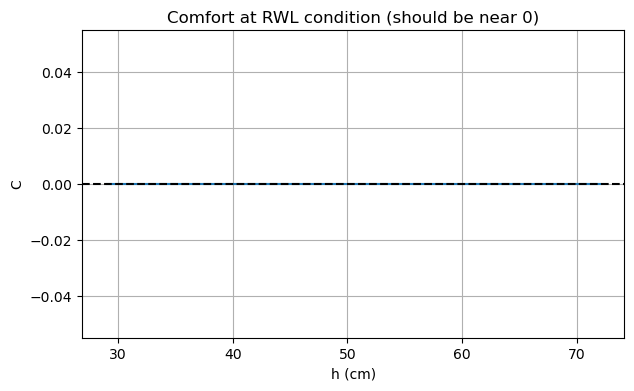

In [11]:
# Validation: comfort is ~0 at RWL
h_check = np.linspace(29, 72, 100)
C_vals = np.array([comfort_score(59.0, rwl_kg(h), h, 168.0) for h in h_check])
print("Max |C| when m_object = RWL:", np.max(np.abs(C_vals)))

plt.figure(figsize=(7, 4))
plt.plot(h_check, C_vals)
plt.axhline(0.0, linestyle="--", color="black")
plt.title("Comfort at RWL condition (should be near 0)")
plt.xlabel("h (cm)")
plt.ylabel("C")
plt.grid(True)
plt.show()

**Plot:** Comfort score `C` vs lifting height when the object mass equals the RWL for each height (`m_object = RWL(h)`). Values near 0 indicate the model matches the comfort threshold.


## 6. Experimental design

We will create three groups of experiments:

1. **Height sweep at RWL condition** (`m_object = RWL(h)`): checks whether predicted load remains near/under accepted limits.
2. **Grid risk map** over object mass and lifting height: visualizes unsafe regions via `LI`, `C`, and estimated L5-S1 resultant force.
3. **Object-mass sensitivity (direct angle sweep)**: compares `F` vs trunk angle `α`.


        h_cm     RWL_kg      F_RWL_N      N_RWL_N  below_3400
0  29.000000  14.423760  2685.702402  2939.367096        True
1  29.544304  14.470033  2691.770662  2945.239759        True
2  30.088608  14.516855  2697.877630  2951.153285        True
3  30.632911  14.564248  2704.024938  2957.109409        True
4  31.177215  14.612233  2710.214299  2963.109956        True
Share below 3400 N: 0.6625


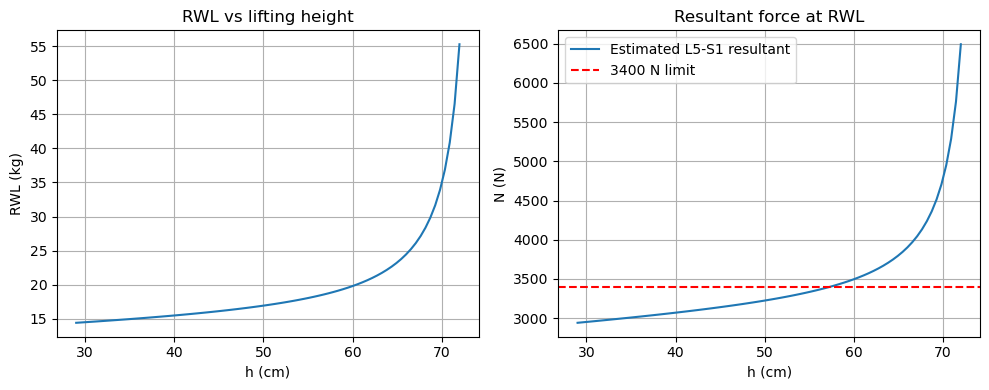

In [12]:
# Height sweep with RWL condition
h_values = np.linspace(29.0, 72.0, 80)
m_body_ref = 59.0
H_ref = 168.0

rows = []
for h in h_values:
    r = rwl_kg(h)
    F_rwl = erector_force_N(m_body_ref, r, h, H_ref)
    N_rwl = l5s1_resultant_N(m_body_ref, r, h, H_ref)
    rows.append({
        "h_cm": h,
        "RWL_kg": r,
        "F_RWL_N": F_rwl,
        "N_RWL_N": N_rwl,
        "below_3400": N_rwl < L5S1_LIMIT_N,
    })

rwl_df = pd.DataFrame(rows)
print(rwl_df.head())
print("Share below 3400 N:", rwl_df["below_3400"].mean())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(rwl_df["h_cm"], rwl_df["RWL_kg"])
plt.title("RWL vs lifting height")
plt.xlabel("h (cm)")
plt.ylabel("RWL (kg)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(rwl_df["h_cm"], rwl_df["N_RWL_N"], label="Estimated L5-S1 resultant")
plt.axhline(L5S1_LIMIT_N, linestyle="--", color="red", label="3400 N limit")
plt.title("Resultant force at RWL")
plt.xlabel("h (cm)")
plt.ylabel("N (N)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot:** 

Left: RWL as a function of lifting height. 

Right: estimated L5-S1 resultant force `N` when lifting at the RWL; the dashed line marks the 3400 N limit.


- `F` is muscle pull required by posture and load.
- `N` is an estimated resultant lumbar load from normal and shear components.
- `LI` compares actual mass to recommended safe mass under the same geometry.
- `C` converts relative overload into an intuitive comfort margin.

Together, these let us quantify not only absolute force, but also relative safety for different workers and tasks.

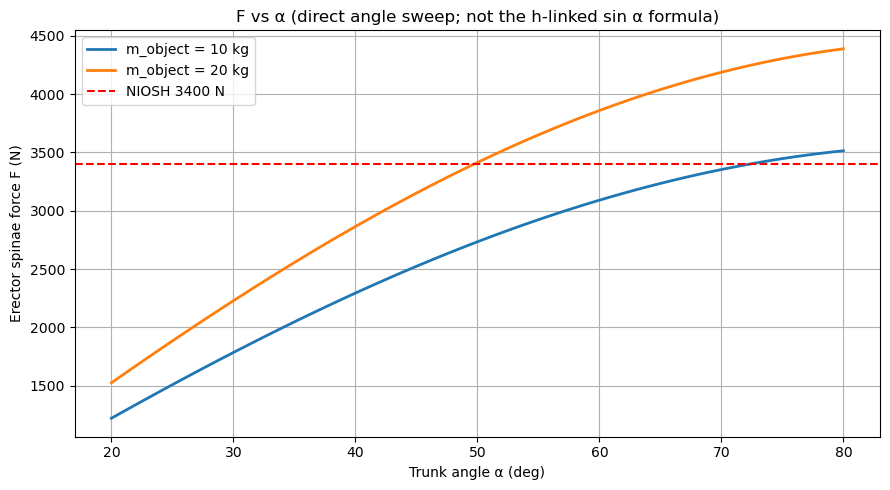

In [13]:
# F vs α with α swept directly
def erector_force_from_alpha_deg(m_body_kg, m_object_kg, alpha_deg, g=G_GRAVITY):
    M = m_body_kg * g
    G = m_object_kg * g
    s = np.sin(np.deg2rad(alpha_deg))
    return (3.42 * M + 9.06 * G) * s


m_body_plot = 80.0  # matches the 10 kg / 20 kg example
angles = np.linspace(20, 80, 61)
F_10kg = np.array([erector_force_from_alpha_deg(m_body_plot, 10.0, a) for a in angles])
F_20kg = np.array([erector_force_from_alpha_deg(m_body_plot, 20.0, a) for a in angles])

plt.figure(figsize=(9, 5))
plt.plot(angles, F_10kg, label="m_object = 10 kg", color="tab:blue", linewidth=2)
plt.plot(angles, F_20kg, label="m_object = 20 kg", color="tab:orange", linewidth=2)
plt.axhline(L5S1_LIMIT_N, color="red", linestyle="--", linewidth=1.5, label="NIOSH 3400 N")
plt.xlabel("Trunk angle α (deg)")
plt.ylabel("Erector spinae force F (N)")
plt.title("F vs α (direct angle sweep; not the h-linked sin α formula)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Plot:** Erector spinae force `F` vs trunk angle `α` for two object masses. As `α` increases, `F` rises; heavier loads shift the curve upward. The red dashed line is the 3400 N benchmark.

                    mean          min          max
h_cm           51.000000    30.000000    72.000000
m_object_kg    20.000000     5.000000    35.000000
F_N          3208.861342  1999.635976  4484.504265
N_N          3474.115022  2196.548395  4805.000798
LI              1.089885     0.090481     2.412263
Comfort        -0.022754    -0.557107     0.648252
Unsafe share: 0.5989247311827957

Risk summary by object mass (rounded kg):
             p_unsafe     median_N  median_LI
m_object_kg                                  
5.0               0.0  2254.483451   0.291846
6.0               0.0  2335.939847   0.350216
7.0               0.0  2417.397193   0.408585
8.0               0.0  2498.855395   0.466954
9.0               0.0  2580.314372   0.525324
10.0              0.0  2661.774054   0.583693
11.0              0.0  2743.234378   0.642062
12.0              0.0  2824.695287   0.700431
13.0              0.0  2906.156733   0.758801
14.0              0.0  2987.618672   0.817170


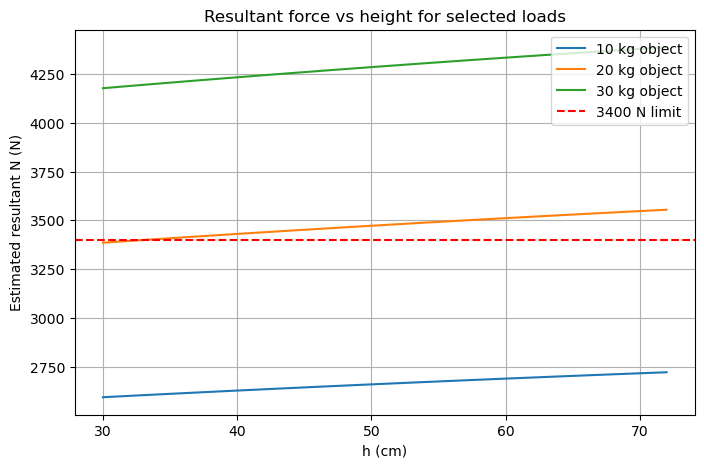

In [14]:
# Risk map across mass and height
m_body = 59.0
H_cm = 168.0
h_grid = np.linspace(30, 72, 30)
m_grid = np.linspace(5, 35, 31)

records = []
for h in h_grid:
    for m_obj in m_grid:
        F = erector_force_N(m_body, m_obj, h, H_cm)
        N = l5s1_resultant_N(m_body, m_obj, h, H_cm)
        LI = lifting_index(m_obj, h)
        C = comfort_score(m_body, m_obj, h, H_cm)
        records.append({
            "h_cm": h,
            "m_object_kg": m_obj,
            "F_N": F,
            "N_N": N,
            "LI": LI,
            "Comfort": C,
            "unsafe": (LI > 1.0) or (N > L5S1_LIMIT_N),
        })

risk_df = pd.DataFrame(records)
print(risk_df.describe().T[["mean", "min", "max"]])
print("Unsafe share:", risk_df["unsafe"].mean())

# Example summarized view by object mass
mass_summary = risk_df.groupby(risk_df["m_object_kg"].round(0)).agg(
    p_unsafe=("unsafe", "mean"),
    median_N=("N_N", "median"),
    median_LI=("LI", "median")
)
print("\nRisk summary by object mass (rounded kg):")
print(mass_summary.head(10))

plt.figure(figsize=(8, 5))
for m_obj in [10, 20, 30]:
    subset = risk_df[np.isclose(risk_df["m_object_kg"], m_obj)]
    plt.plot(subset["h_cm"], subset["N_N"], label=f"{int(m_obj)} kg object")
plt.axhline(L5S1_LIMIT_N, linestyle="--", color="red", label="3400 N limit")
plt.xlabel("h (cm)")
plt.ylabel("Estimated resultant N (N)")
plt.title("Resultant force vs height for selected loads")
plt.legend()
plt.grid(True)
plt.show()

**Plot:** Estimated L5-S1 resultant force `N` vs lifting height for selected object masses (10, 20, 30 kg). Where curves exceed 3400 N, the task geometry becomes likely unsafe.


## 7. Conclusions

The model reproduces the expected biomechanical trends: increasing object mass and/or worsening lifting geometry increases the estimated lumbar force and reduces the comfort margin.

**Key takeaways**
1. RWL-based interpretation (`LI`, `C`) provides a safety decision criterion aligned with accepted limits (e.g., 3400 N), not just an absolute force.
2. Simulation results highlight unsafe regions that grow quickly as object mass increases and lifting height changes.

**Limitations**
- This is a static sagittal formulation; dynamics, torsion, and individual personalization are not included.



